# Advanced Cloud Clearing in Sentinel-2: combining spectral and clustering approaches

Our goal here is to prepare a Sentinel-2 image over a region of interest and create a cloud-clearing function that uses both:
- Spectral characteristics of clouds (e.g., high reflectance in blue, low in SWIR)
- A clustering algorithm (e.g., k-means or DBSCAN (but do feel free to use whatever you think is best) on pixel features) to find and expand cloud-masked areas to include neighboring “cloudy-ish” pixels.

My intent is that by the end of this lab you have a function that you can then use in many of your project workflows to ensure that the data you are using is as free of clouds as possible (you will need to re-design it if apply to imagery other than Sentinel 2).

The overview of our workflow is to:
- Load and filter on location, date and overall cloud contamination > Sentinel-2 surface reflectance imagery in Earth Engine.
- Apply the s2cloudless cloud probability algorithm.
- Apply a clustering approach to detect “borderline” cloudy pixels near heavy clouds.
- Generate a clean composite for a chosen date range.

We are using this tutorial from Google as the basis of our work: [Sentinel-2 Cloud Masking with s2cloudless](https://developers.google.com/earth-engine/tutorials/community/sentinel-2-s2cloudless).


**As ever, in this lab whenever we ask you for an visual output, we are expecting you to present it to a publication quality level.**


________________________________________________________________________________
# Implementing S2 Cloudless

In [18]:
# Our usual set up routine
!pip install geemap --quiet

import geemap
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans

import ee
ee.Authenticate()
ee.Initialize(project='earthenginetest-504004')
# ee.Initialize(project='earthengine-ml-testing') #<- Remember to change this to your own project's name!

First, let us define our area of interest (AOI) and the cloud mask parameters, here is the table from the Earth Engine Catalogue: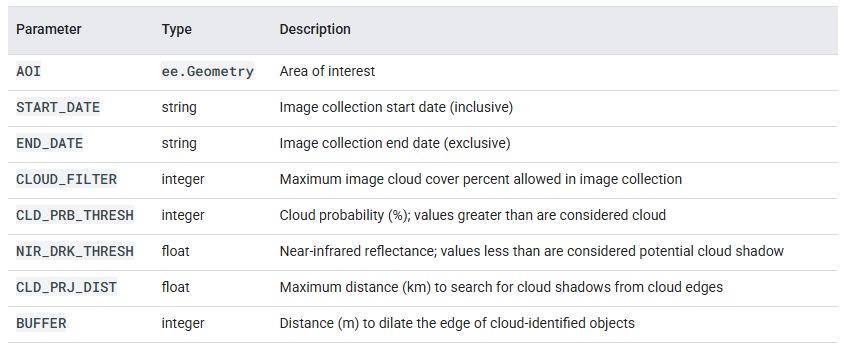

In [19]:
# Control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50

Next we use these variables to build a Sentinel 2 image collection. You have done all this before, but now we are using more of the tools at our disposal to get exactly what we want.

Also, from now on we are going to be using functions to make our code more useable and extensible:

In [20]:
def get_s2_sr_cld_col(aoi, start_date, end_date):
    # Import and filter S2 SR.
    s2_sr_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', CLOUD_FILTER)))

    # Import and filter s2cloudless.
    s2_cloudless_col = (ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY')
        .filterBounds(aoi)
        .filterDate(start_date, end_date))

    # Join the filtered s2cloudless collection to the SR collection by the 'system:index' property.
    return ee.ImageCollection(ee.Join.saveFirst('s2cloudless').apply(**{
        'primary': s2_sr_col,
        'secondary': s2_cloudless_col,
        'condition': ee.Filter.equals(**{
            'leftField': 'system:index',
            'rightField': 'system:index'
        })
    }))

In [21]:
# Apply the function in order to generate the collection
s2_sr_cld_col_eval = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

In [22]:
# As ever, a good idea to do a quick viusalization check
Map = geemap.Map(basemap="HYBRID")
Map.centerObject(AOI, 10)
Map.addLayer(s2_sr_cld_col_eval, {'bands':['B4','B3','B2'], 'min':0, 'max':3000}, 'S2 collection (before)')
Map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Yup that is pretty cloudy!

Now, we will define a function to add the s2cloudless probability layer and derived cloud mask as bands to an S2 SR image input.

In [23]:
def add_cloud_bands(img):
    # Get s2cloudless image, subset the probability band.
    cld_prb = ee.Image(img.get('s2cloudless')).select('probability')

    # Condition s2cloudless by the probability threshold value.
    is_cloud = cld_prb.gt(CLD_PRB_THRESH).rename('clouds')

    # Add the cloud probability layer and cloud mask as image bands.
    return img.addBands(ee.Image([cld_prb, is_cloud]))

The next function we need adds bands that adds layers that identify dark pixels, cloud projection, and identified shadows as bands to an S2 SR image input. Note that the image input needs to be the result of the above add_cloud_bands function because it relies on knowing which pixels are considered cloudy (via the renamed 'CLD_PRB_THRESH' band native to this S2 product).

In [24]:
def add_shadow_bands(img):
    # Identify water pixels from the SCL band.
    not_water = img.select('SCL').neq(6)

    # Identify dark NIR pixels that are not water (potential cloud shadow pixels).
    SR_BAND_SCALE = 1e4
    dark_pixels = img.select('B8').lt(NIR_DRK_THRESH*SR_BAND_SCALE).multiply(not_water).rename('dark_pixels')

    # Determine the direction to project cloud shadow from clouds (assumes UTM projection).
    shadow_azimuth = ee.Number(90).subtract(ee.Number(img.get('MEAN_SOLAR_AZIMUTH_ANGLE')));

    # Project shadows from clouds for the distance specified by the CLD_PRJ_DIST input.
    cld_proj = (img.select('clouds').directionalDistanceTransform(shadow_azimuth, CLD_PRJ_DIST*10)
        .reproject(**{'crs': img.select(0).projection(), 'scale': 100})
        .select('distance')
        .mask()
        .rename('cloud_transform'))

    # Identify the intersection of dark pixels with cloud shadow projection.
    shadows = cld_proj.multiply(dark_pixels).rename('shadows')

    # Add dark pixels, cloud projection, and identified shadows as image bands.
    return img.addBands(ee.Image([dark_pixels, cld_proj, shadows]))

Finally for this stage, we define a function to assemble all of the cloud and cloud shadow components and produce the final mask.

In [25]:
def add_cld_shdw_mask(img):
    # Add cloud component bands.
    img_cloud = add_cloud_bands(img)

    # Add cloud shadow component bands.
    img_cloud_shadow = add_shadow_bands(img_cloud)

    # Combine cloud and shadow mask, set cloud and shadow as value 1, else 0.
    is_cld_shdw = img_cloud_shadow.select('clouds').add(img_cloud_shadow.select('shadows')).gt(0)

    # Remove small cloud-shadow patches and dilate remaining pixels by BUFFER input.
    # 20 m scale is for speed, and assumes clouds don't require 10 m precision.
    is_cld_shdw = (is_cld_shdw.focalMin(2).focalMax(BUFFER*2/20)
        .reproject(**{'crs': img.select([0]).projection(), 'scale': 20})
        .rename('cloudmask'))

    # Add the final cloud-shadow mask to the image.
    return img_cloud_shadow.addBands(is_cld_shdw)

Let us check this out and see how well it is dealing with our famously cloudy country. To do this we will need a function to pull out the cloud masking component layers, as in the 'final' version we will just apply this layer to remove the clouds rather than hold it as something we will display.

In [26]:
def display_cloud_layers_geemap(col, AOI):
    # Mosaic the image collection.
    img = col.mosaic()

    # Subset layers and prepare them for display.
    clouds = img.select('clouds').selfMask()
    shadows = img.select('shadows').selfMask()
    dark_pixels = img.select('dark_pixels').selfMask()
    probability = img.select('probability')
    cloudmask = img.select('cloudmask').selfMask()
    cloud_transform = img.select('cloud_transform')

    # Create a geemap Map object centered on AOI.
    m = geemap.Map(basemap='HYBRID')
    m.centerObject(AOI, 12)

    # Add layers
    m.addLayer(img, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500, 'gamma': 1.1}, 'S2 image')
    m.addLayer(probability, {'min': 0, 'max': 100}, 'probability (cloud)')
    m.addLayer(clouds, {'palette': ['e056fd']}, 'clouds')
    m.addLayer(cloud_transform, {'min': 0, 'max': 1, 'palette': ['white', 'black']}, 'cloud_transform')
    m.addLayer(dark_pixels, {'palette': ['orange']}, 'dark_pixels')
    m.addLayer(shadows, {'palette': ['yellow']}, 'shadows')
    m.addLayer(cloudmask, {'palette': ['orange']}, 'cloudmask')

    return m

The cell you are about to run, is going to open with a whole lot of layers! Use the layer menu top right of the map to turn them all off except the Sentinel 2 image that we are trying to find the cloud in. Then, one by one add in each layer (which is each a part of the cloud clearing algorithim), and look at what 'part' of the cloud problem it is dealing with. Examine how well it is performing and think about what characteristics it is making the decision to label a given pixel as the given target on.

In [27]:
s2_sr_cld_col_eval_disp = s2_sr_cld_col_eval.map(add_cld_shdw_mask)
display_map = display_cloud_layers_geemap(s2_sr_cld_col_eval_disp, AOI)
display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Well now! That is considerably better than what we have been using before!

(1) Zoom in to a cloudy region and look at the S2 image, 'clouds' layer, 'dark pixels',  and the 'shadows' layers. Write a short paragraph that discusses:
- The performance of each masking element. Are they perfect or getting confused? What is causing the confusion?
- How do the three elements work together to define pixels that are not clear?
I am looking for you to show an understanding of both the algorithim you have just applied and the underlying spectral sensing principles.

(10 pts)

**Answer:** When I zoomed into a cloudy patch in the S2 output, each masking layer behaved mostly as expected but with some noticeable imperfections. The clouds layer generally picked up the bright, opaque cloud tops well, but it occasionally got confused by other very bright surfaces such as things like pale rooftops or reflective ground patches, which mimic the same high reflectance across visible bands. The dark‑pixels layer was much noisier on its own; it flagged plenty of dark areas that clearly weren’t cloud shadows, such as dense vegetation or naturally dark soil, simply because they absorb strongly in the NIR. The shadows layer felt more precise, since it only highlighted dark pixels that fell in the predicted shadow‑direction zone relative to the detected clouds, but even then, thin clouds or partial cloud edges sometimes produced weaker or incomplete shadow matches. When all three layers are combined, the logic becomes clearer: bright‑pixel detection suggests where clouds might be, dark‑pixel detection suggests where shadows might be, and the geometric projection ties those two together so only the dark pixels that make physical sense (i.e., in the right place relative to the sun and cloud position) are kept. None of the individual masks is perfect, but together they form a more reliable picture of which pixels are “not clear,” blending spectral cues with physical constraints to reduce false positives.

(2) Exercise: change the above CLD_PRB_THRESH, NIR_DRK_THRESH, CLD_PRJ_DIST, and BUFFER input variables and rerun the previous cells to see how the results change. Present a figure that compares between the first version you ran and your final version. State the values you have selected and describe the improvements in performance you have managed to achieve in the figure caption.

(10 pts)

In [39]:
# 1. Define Area of Interest (AOI) and Date Range
aoi = ee.Geometry.Point([-122.27, 37.87]) # Example ROI (Berkeley, CA) - update as needed

start_date = '2022-06-01'
end_date = '2022-08-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 40
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50

# 2. Fetch Sentinel-2 Surface Reflectance and s2cloudless Collections
s2_sr_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
             .filterBounds(aoi)
             .filterDate(start_date, end_date)
             .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', CLOUD_FILTER)))

s2_cloudless_col = (ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY')
                    .filterBounds(aoi)
                    .filterDate(start_date, end_date))

# Join collections on system:index
joined_col = ee.ImageCollection(ee.Join.saveFirst('s2cloudless').apply(
    primary=s2_sr_col,
    secondary=s2_cloudless_col,
    condition=ee.Filter.equals(leftField='system:index', rightField='system:index')
))

# 3. Define Advanced Cloud and Shadow Masking Function
def add_cloud_bands(img):
    cld_prb = ee.Image(img.get('s2cloudless')).select('probability')
    is_cloud = cld_prb.gt(CLD_PRB_THRESH).rename('clouds')

    # Shadow identification using SWIR / NIR reflectance
    dark_pixels = img.select('B8').lt(NIR_DRK_THRESH*10000).rename('dark_pixels')
    shadows = dark_pixels.And(is_cloud.Not()).rename('shadows')

    # cloud_mask = is_cloud.or_(shadows)
    cloud_mask = is_cloud.Or(shadows)
    return img.addBands([cld_prb, is_cloud, shadows, cloud_mask])

# Apply cloud probability mask
processed_col = joined_col.map(add_cloud_bands)
single_img = ee.Image(processed_col.first())

# 4. Apply K-Means Clustering for Borderline "Cloudy-ish" Pixel Masking
# Extract spectral bands suitable for cloud/shadow discrimination (Blue, Green, Red, NIR, SWIR1, SWIR2)
bands = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']
img_to_cluster = single_img.select(bands)

# Sample pixels within the AOI for unsupervised K-Means training
training_samples = img_to_cluster.sample(
    region=aoi.buffer(10000),
    scale=10,
    numPixels=5000,
    seed=42
)

# Instantiate and train Clusterer (k=5 clusters)
clusterer = ee.Clusterer.wekaKMeans(nClusters=5).train(training_samples)
clustered_img = img_to_cluster.cluster(clusterer).rename('clusters')

# Identify clusters that overlap significantly with high cloud probability areas
cloud_probability = single_img.select('probability')
high_prob_cloud = cloud_probability.gt(CLD_PRB_THRESH)

# Mask image combining s2cloudless and cluster-based region expansion
final_cloud_mask = single_img.select('cloud_mask').Or(
    clustered_img.eq(1) # Assuming cluster 1 captures cloudy-ish/edge spectral features
).focalMax(radius=BUFFER, units='meters')

cleaned_img = single_img.updateMask(final_cloud_mask.Not())

# 5. Publication-Quality Visualization
Map = geemap.Map()
Map.centerObject(aoi, 11)

vis_rgb = {'min': 0, 'max': 3000, 'bands': ['B4', 'B3', 'B2']}
vis_mask = {'min': 0, 'max': 1, 'palette': ['white', 'red']}

Map.addLayer(single_img, vis_rgb, 'Original Sentinel-2 RGB')
Map.addLayer(single_img.select('probability'), {'min': 0, 'max': 100, 'palette': ['blue', 'yellow', 'red']}, 's2cloudless Probability')
Map.addLayer(final_cloud_mask, vis_mask, 'Final Combined Mask (Spectral + Clustering)')
Map.addLayer(cleaned_img, vis_rgb, 'Cloud-Cleared Image Composite')

Map

EEException: Image.select: Band pattern 'cloud_mask' did not match any bands. Available bands: [B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, B11, B12, AOT, WVP, SCL, TCI_R, TCI_G, TCI_B, MSK_CLDPRB, MSK_SNWPRB, QA10, QA20, QA60, MSK_CLASSI_OPAQUE, MSK_CLASSI_CIRRUS, MSK_CLASSI_SNOW_ICE, probability, clouds, shadows, clouds_1]

In [40]:
# Fixed Cloud and Shadow Masking Function
def add_cloud_bands(img):
    cld_prb = ee.Image(img.get('s2cloudless')).select('probability')
    is_cloud = cld_prb.gt(CLD_PRB_THRESH).rename('clouds')

    # Shadow identification using SWIR / NIR reflectance
    dark_pixels = img.select('B8').lt(NIR_DRK_THRESH * 10000).rename('dark_pixels')
    shadows = dark_pixels.And(is_cloud.Not()).rename('shadows')

    # Explicitly name the combined band 'cloud_mask'
    cloud_mask = is_cloud.Or(shadows).rename('cloud_mask')

    return img.addBands([cld_prb, is_cloud, shadows, cloud_mask])

# Apply cloud probability mask
processed_col = joined_col.map(add_cloud_bands)
single_img = ee.Image(processed_col.first())

# 4. Apply K-Means Clustering for Borderline "Cloudy-ish" Pixel Masking
bands = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']
img_to_cluster = single_img.select(bands)

# Sample pixels within the AOI for unsupervised K-Means training
training_samples = img_to_cluster.sample(
    region=aoi.buffer(10000),
    scale=10,
    numPixels=5000,
    seed=42
)

# Instantiate and train Clusterer (k=5 clusters)
clusterer = ee.Clusterer.wekaKMeans(nClusters=5).train(training_samples)
clustered_img = img_to_cluster.cluster(clusterer).rename('clusters')

# Mask image combining s2cloudless and cluster-based region expansion
final_cloud_mask = single_img.select('cloud_mask').Or(
    clustered_img.eq(1) # Cluster capturing cloudy-ish/edge spectral features
).focalMax(radius=BUFFER, units='meters')

cleaned_img = single_img.updateMask(final_cloud_mask.Not())

# 5. Publication-Quality Visualization
Map = geemap.Map()
Map.centerObject(aoi, 11)

vis_rgb = {'min': 0, 'max': 3000, 'bands': ['B4', 'B3', 'B2']}
vis_mask = {'min': 0, 'max': 1, 'palette': ['white', 'red']}

Map.addLayer(single_img, vis_rgb, 'Original Sentinel-2 RGB')
Map.addLayer(single_img.select('probability'), {'min': 0, 'max': 100, 'palette': ['blue', 'yellow', 'red']}, 's2cloudless Probability')
Map.addLayer(final_cloud_mask, vis_mask, 'Final Combined Mask (Spectral + Clustering)')
Map.addLayer(cleaned_img, vis_rgb, 'Cloud-Cleared Image Composite')

Map

Map(center=[37.87, -122.27], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

Finally for this section, let's apply this cloud mask to our data and generate a 'cloud free' image. Replace my parameters used below with the ones you have selected based on your answer to question 2.

In [41]:
# Tweaked control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50

# Re-collect the S2 as we have changed our filtering params
s2_sr_cld_col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

In [42]:
# Define a function to apply the cloud mask to the S2 spectral bands
def apply_cld_shdw_mask(img):
    cloudmask = img.select('cloudmask')
    # Mask cloudy pixels
    masked_img = img.updateMask(cloudmask.Not())
    # Keep cloudmask and probability bands
    cloudmask_band = img.select('cloudmask')
    probability_band = img.select('probability')
    masked_img = masked_img.addBands([cloudmask_band, probability_band], overwrite=True)
    return masked_img

In [43]:
# Process the collection
s2_sr_median = (s2_sr_cld_col.map(add_cld_shdw_mask)
                             .map(apply_cld_shdw_mask)
                             .median())

In [44]:
# Display the cloud free composite
def display_cloud_free_mosaic(s2_sr_median, AOI):
    # Create a geemap Map object and center it on the AOI
    m = geemap.Map(basemap='HYBRID')
    m.centerObject(AOI, 12)

    # Add the Sentinel-2 RGB mosaic
    m.addLayer(
        s2_sr_median,
        {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500, 'gamma': 1.1},
        'S2 cloud-free mosaic')

    return m

display_map = display_cloud_free_mosaic(s2_sr_median, AOI)
display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Now THAT is a cloud-free image! (Well, with my thresholds we still have a little there over the SW forest, can yours do better?).

(3) This process has managed to avoid masking out the many bright white roofs of Auckland as cloud, despite them appearing very similar to cloud in the RGB visualization. How has the algorithm achieved this?
(5 pts)


________________________________________________________________________________

**Answer:** The reason this algorithm doesn't mistake Auckland's bright white roofs for clouds comes down to how it looks at light beyond what the human eye can see.

While a painted roof and a fluffy cloud look nearly identical in standard red, green, and blue (RGB) images, they behave completely differently under shortwave infrared (SWIR) light. Clouds are made of water droplets and ice crystals that absorb shortwave infrared light, making them look dark in SWIR bands. Urban roofs, on the other hand, reflect this light strongly. The s2cloudless model checks these extra spectral bands, so even if a roof is glaringly white, its high infrared reflection tells the system it is solid building material rather than a cloud.

On top of that, the algorithm doesn't just rely on a basic brightness check. It uses a machine learning model trained on satellite data from all over the world. Instead of asking "Is this pixel bright?", it analyzes how all the spectral bands work together at once. Because it evaluates these complex pattern combinations, it easily separates urban infrastructure from actual weather features. Finally, the algorithm looks for nearby cloud shadows; since stationary white buildings don't create high-altitude cloud shadows on the surrounding ground, they stay safely unmasked.

# Extending S2 Cloudless with a clustering approach
The process we explored in the prior section has worked really rather well! But you saw in the exercise that it does rely on you setting the local paramaters. This is a manual process and one that is at risk of reduced effectiveness if we are clearing cloud over a wide area. This is particularly the case for cirrus and other thin clouds (e.g. cloud edges) that the thresholds are very sensitive to.

Therefore, let us extend our cloud-clearing algorithim into one that includes a clustering-step in which we sample the pixels around the edge of our clouds and test if they should be clustered into our cloud mask.

We will now implement the following workflow:
1.   Reset our data stack, with somewhat worse settings than the very good ones we have just set, in order to make this a better (for humans) teaching exercise.
2.   Define what counts as inside a cloud, outside a cloud and the edge of a cloud.
3.   Vizualize these samples and determine if we can perform meaningful clustering on them.
4.   Perform clustering of the border zone pixels with either the clouds or the cloud free.





In [45]:
# First, lets make our cloud clearing 'worse' in order to more clearly demonstrate our clustering alg
# Tweaked control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 30
CLD_PRB_THRESH = 30
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 5

# Re-collect the S2 as we have changed our filtering params
s2_sr_cld_col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

# Re-run s2cloudless approach, this time with .moasic as the compositing operator
s2_sr_mosaic = (s2_sr_cld_col.map(add_cld_shdw_mask)
                             .map(apply_cld_shdw_mask)
                             .mosaic()) #<- switched to mosaic to better preserve the cloud masking layers we want to now use for our k-means workflow

In [46]:
def define_cloud_zones(img, edge_buffer=120):
    cloudmask = img.select('cloudmask')

    # Interior cloud pixels: cloudmask==1, away from edges (small erosion)
    cloud_interior = cloudmask.selfMask().focal_min(3)

    # Interior clear pixels: cloudmask==0, away from edges (medium erosion)
    clear_interior = cloudmask.Not().selfMask().focal_min(10)

    # Cloud edge pixels: buffer zone around clouds, but outside cloudmask
    cloud_edge = cloudmask.focal_max(edge_buffer / 10).And(cloudmask.Not())

    return cloud_interior, clear_interior, cloud_edge


In [47]:
def sample_zones(img, AOI, edge_buffer=20):
    cloudmask = img.select('cloudmask')

    cloud_interior = cloudmask.selfMask()
    clear_interior = cloudmask.Not().selfMask()
    cloud_edge = cloudmask.focal_max(edge_buffer).And(cloudmask.Not())

    sample_bands = ['B2', 'B3', 'B4', 'B5', 'B6' , 'B9', 'B8', 'B11', 'B12']
    if 'probability' in img.bandNames().getInfo():
        sample_bands.append('probability')

    img_for_sampling = img.select(sample_bands)

    cloud_samples = img_for_sampling.updateMask(cloud_interior).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=0, geometries=True)

    clear_samples = img_for_sampling.updateMask(clear_interior).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=1, geometries=True)

    edge_samples = img_for_sampling.updateMask(cloud_edge).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=2, geometries=True)

    return cloud_samples, clear_samples, edge_samples


In [48]:
# Gather our samples
cloud_samples, clear_samples, edge_samples = sample_zones(s2_sr_mosaic, AOI)

# Function to convert a earth engine feature class to a pandas df
def fc_to_df(fc):
    features = fc.getInfo()['features']
    rows = []
    for f in features:
        props = f['properties']
        coords = f['geometry']['coordinates']
        props['longitude'] = coords[0]
        props['latitude'] = coords[1]
        rows.append(props)
    return pd.DataFrame(rows)


# Carry out the conversion and sanity print out what we have
cloud_df = fc_to_df(cloud_samples)
clear_df = fc_to_df(clear_samples)
edge_df = fc_to_df(edge_samples)

print(f"Cloud samples: {len(cloud_df)}")
print(f"Clear samples: {len(clear_df)}")
print(f"Edge samples: {len(edge_df)}")
print("Cloud columns:", cloud_df.columns)


Cloud samples: 893
Clear samples: 3239
Edge samples: 2856
Cloud columns: Index(['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B8', 'B9', 'probability',
       'longitude', 'latitude'],
      dtype='object')


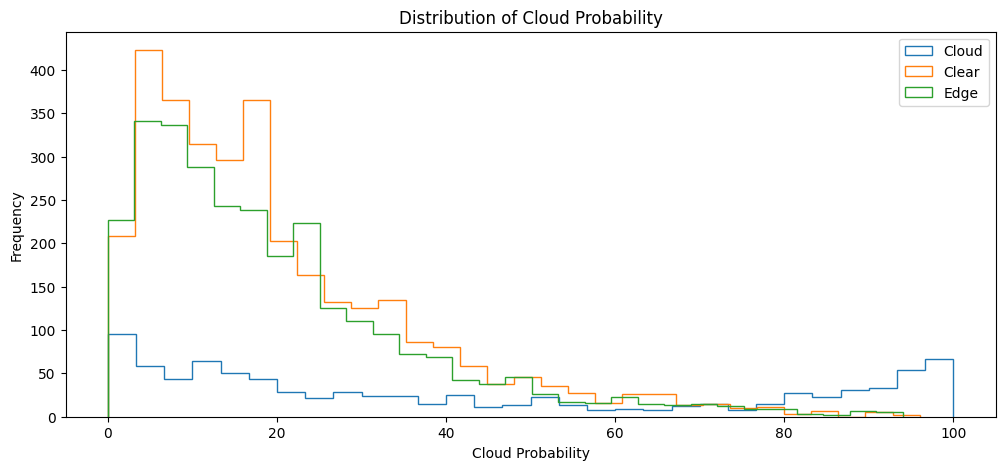

In [49]:
# Histogram of cloud probability by class
plt.figure(figsize=(12, 5))
plt.hist(cloud_df['probability'], bins=30, histtype='step', label='Cloud')
plt.hist(clear_df['probability'], bins=30, histtype='step', label='Clear')
plt.hist(edge_df['probability'], bins=30, histtype='step', label='Edge')
plt.xlabel('Cloud Probability')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Cloud Probability')
plt.show()

Look at the histogram above. What is it telling you about the quality of the training classes you have just created? Think back to Lab 1, and the lecture 2/3 exercises.

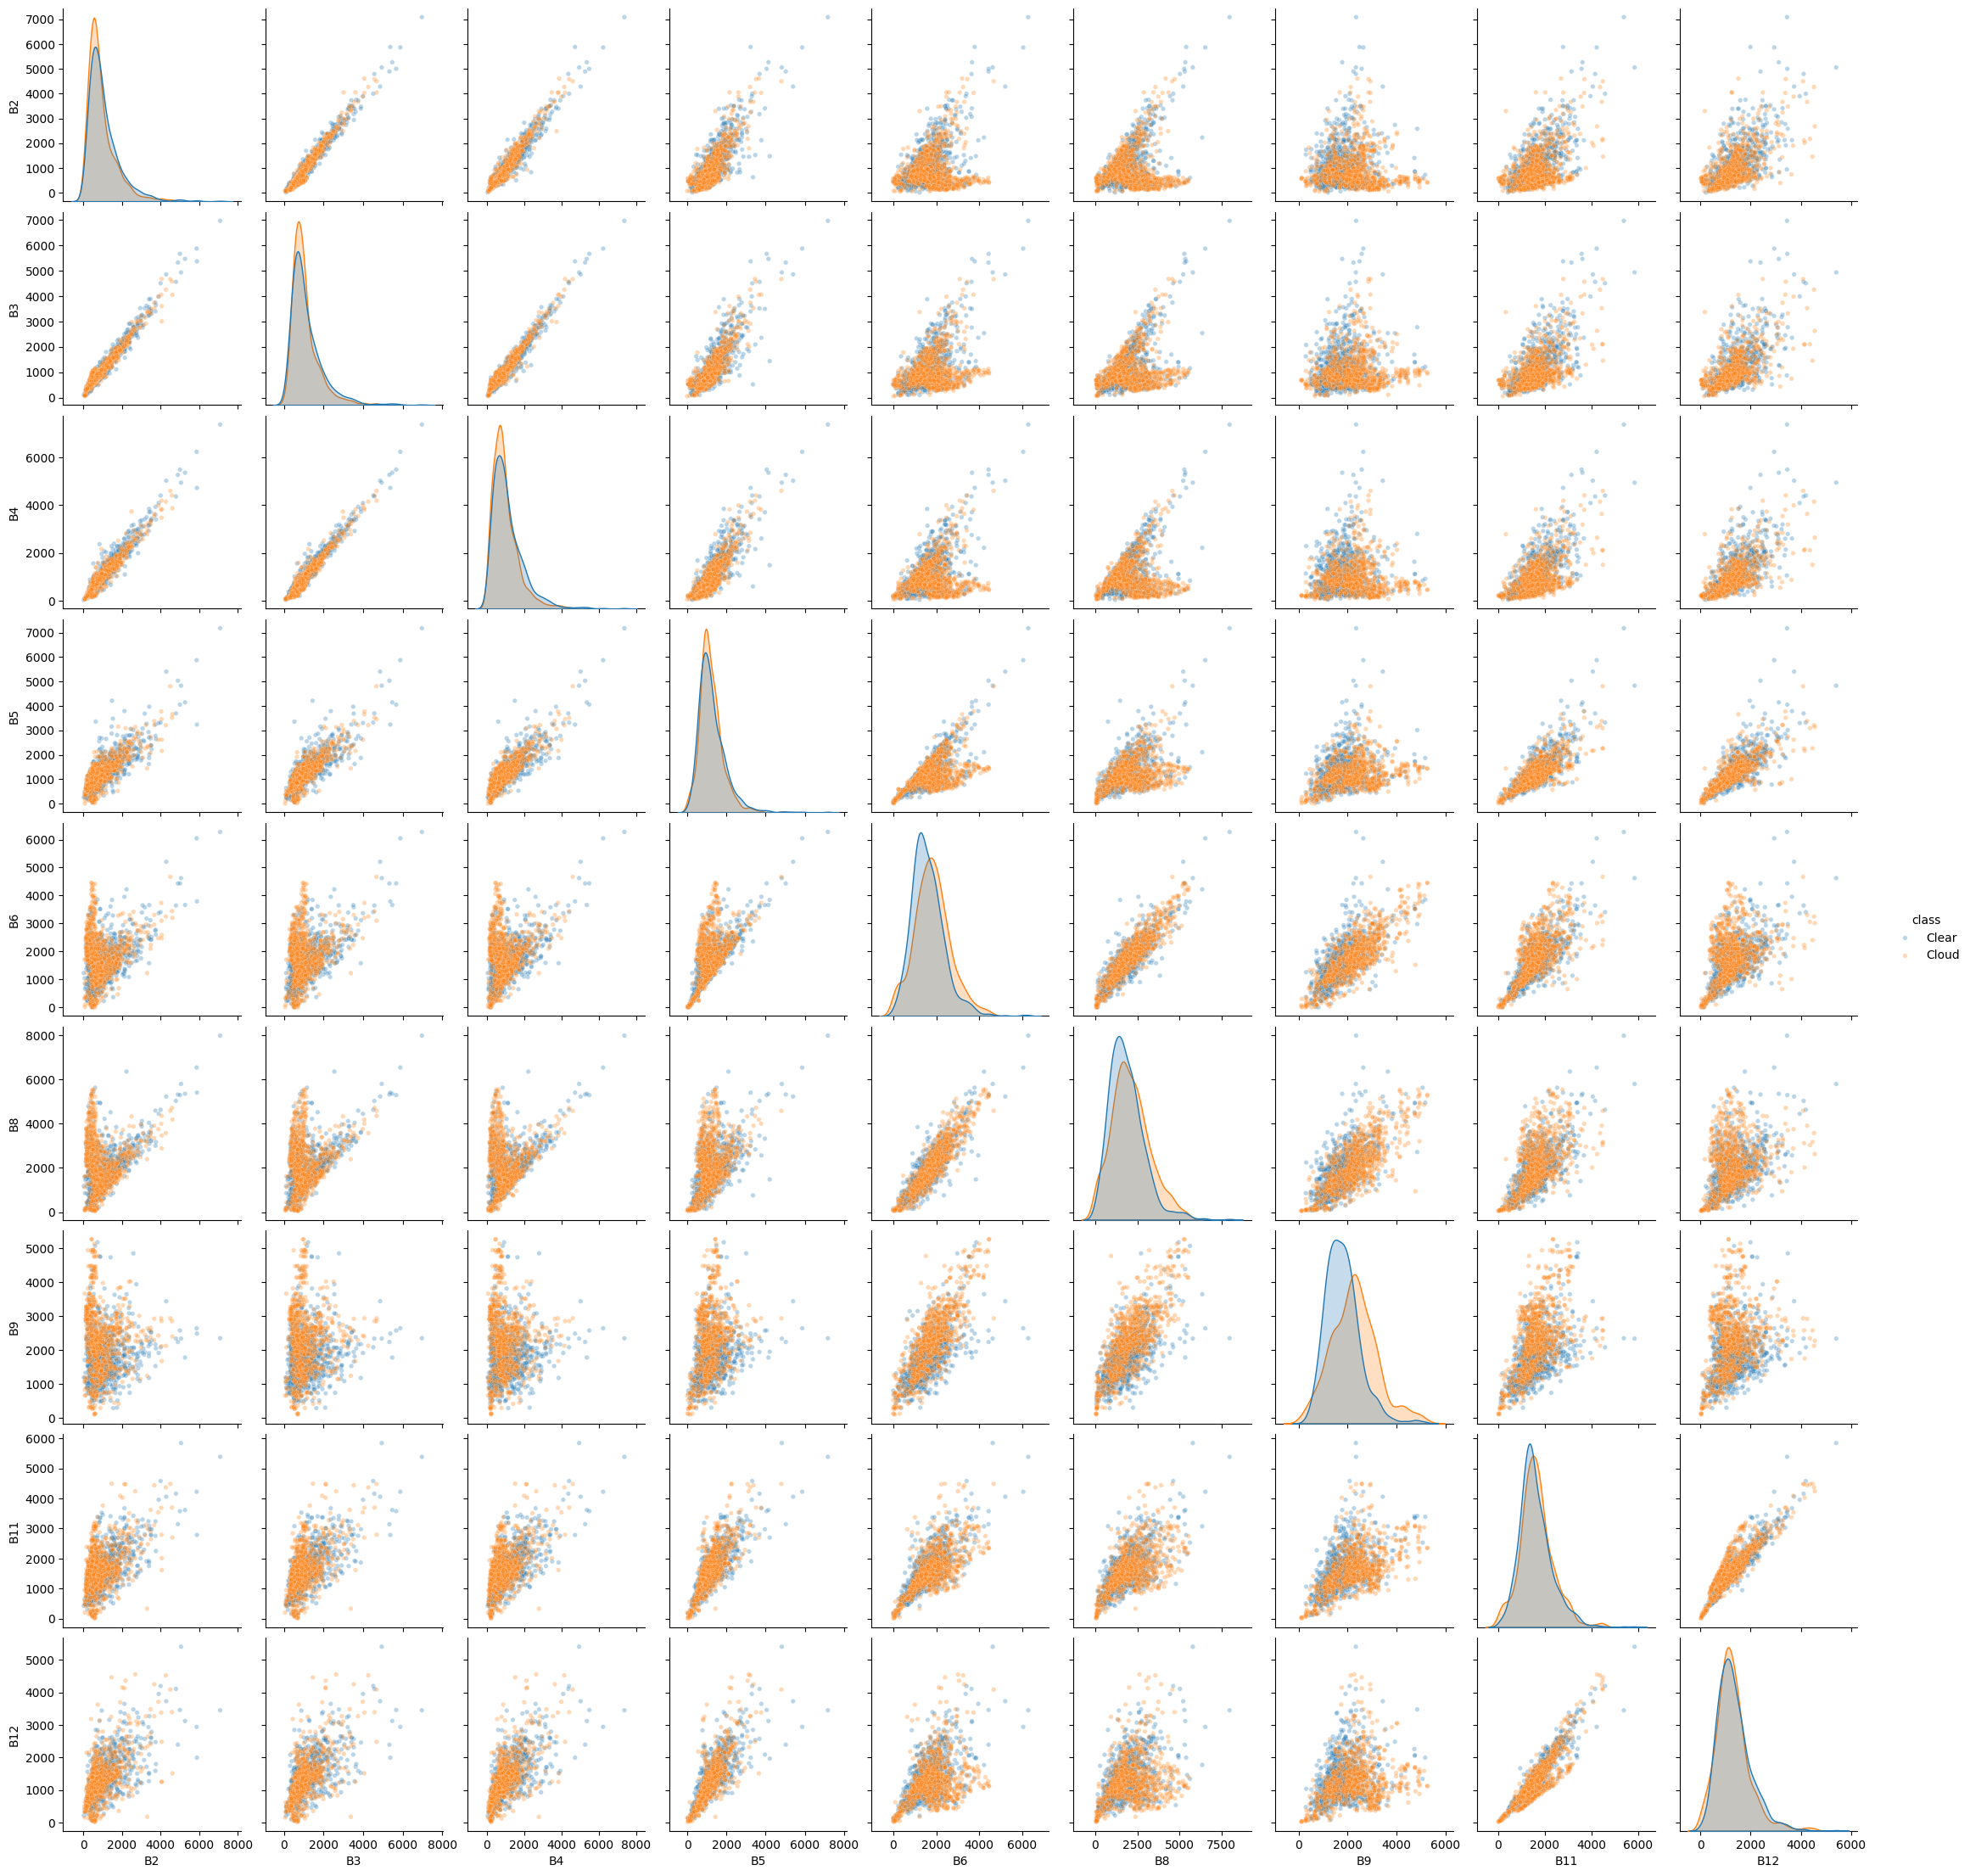

In [50]:
# Plot out all the bands, by the two 'labelled' classes that we want to discriminate between
# Add class labels
cloud_df['class'] = 'Cloud'
clear_df['class'] = 'Clear'

# Combine to one df
combined_df = pd.concat([cloud_df, clear_df])

# We will carry out somne class balancing here
# Find smallest class count
min_count = combined_df['class'].value_counts().min()

# Downsample each class to min_count
balanced_df = combined_df.groupby('class').sample(n=min_count, random_state=42)

# Now plot with balanced_df
# This is going to make a big plot that you will have to scroll around! Pay particular attention to the histogram plots on the diagonal.
bands = ['B2', 'B3', 'B4', 'B5', 'B6' , 'B8', 'B9', 'B11', 'B12']
sns.pairplot(balanced_df, vars=bands, hue='class', plot_kws={'alpha':0.3, 's':15}, height=2.5)


(4) What do the histograms of cloud detection probability (as judged by s2cloudless) plotted in the three classes we have set here, AND the pair plot of all bands available tell us about our ability to tell cloudy vs non-cloud pixels apart? Make sure to explain your answer with reference to physical principles and the statistical foundations of ML (5 pts)

**Answer:** When looking at the s2cloudless cloud probability histograms across our three classes (clear, thin/cloudy-ish, and dense cloud core), we are essentially inspecting the model's prediction confidence across different surface types. A well-performing model produces a clear bimodal distribution, where clear pixels pile up near $0.0$ probability and dense cloud cores stack up near **1.0**. The overlapping region in the middle—usually between **20\%** and **60\%** probability represents the model's classification uncertainty. Physically, this uncertainty happens because thin cirrus clouds, haze, or highly reflective ground features like bright sand, concrete, and snow bounce light back to the sensor in ways that closely mimic real clouds.The pair plots of all available spectral bands take this analysis a step further by showing us how different wavelengths interact with one another in a multi-dimensional feature space. Statistically, bands that show tight, diagonal scatter plots (like Red versus Green) have high covariance, meaning they carry redundant information and do not help much in separating classes.Where the pair plots really shine is in highlighting non-linear decision boundaries, particularly when pairing visible or Near-Infrared (NIR) bands with Shortwave Infrared (SWIR) bands. This is where physical principles come into play:
- Clouds reflect strongly across almost all visible, NIR, and SWIR wavelengths, making them bright across the board.
- Vegetation scatters NIR heavily due to its leaf structure, but absorbs SWIR due to moisture content.
- Water absorbs almost all light in the NIR and SWIR regions, showing up as extremely dark.
- Bright land and soil retain high reflectance in the SWIR range, whereas clouds drop off in specific SWIR wavelengths.

By evaluating these pair plots, we can visually identify which band combinations pull these class clusters furthest apart, proving where linear separation is possible and where a clustering algorithm like **K-Means** will need to step in.

(5) Which bands are therefore going to be the best to use in our K-means clustering approach and why? (5 pts)

**Answer:** Because **K**-Means calculates the straight-line Euclidean distance between data points in an **N**-dimensional space, feeding it every available band is actually counterproductive. Bands that are highly correlated distort the distance math by essentially double-counting the same spectral information, which dilutes the algorithm's ability to spot real differences. To get the cleanest cloud separation, we want a lean, non-redundant subset of bands that maximizes contrast based on surface physics.The optimal bands to select for **K**-Means include:
- Aerosol / Blue (B1 or B2): Short wavelengths undergo strong atmospheric scattering and reflect heavily off clouds, creating maximum statistical contrast between atmospheric features and darker ground cover like vegetation or water.
- Near-Infrared / NIR (B8 or B8A): Essential for pulling vegetation and water away from clouds. While plants look bright in visible light just like clouds do, NIR highlights the unique structure of healthy leaves and immediately sets them apart.
- Shortwave Infrared / SWIR (B11 and/or B12): This is the ultimate tie-breaker for telling clouds apart from bright ground targets like sand, rocks, or concrete. Land surfaces stay bright in the SWIR bands, whereas moisture and ice inside clouds absorb SWIR light, causing their signal to drop off significantly.

By excluding intermediate bands like Red and Green—which mostly repeat what Blue and NIR already tell us—we reduce the dimensionality of our feature space. This speeds up **K**-Means convergence and ensures the algorithm clusters pixels based on meaningful physical properties rather than redundant spectral noise.

With our choices made, let us now test if we can implement k-means as a tool by which to assign those edge pixels into either the cloudy or clear classes. Noting that I have placed default band choices in the 'features to use for clustering' line. You do not need to use just three bands.

Run this section first with the default bands, and then change it to the ones you have selected in question 5. Observe the difference it makes...

In [51]:
# Use the balanced_df from before for cloud and clear pixels only
train_df = balanced_df[balanced_df['class'].isin(['Cloud', 'Clear'])]

# Features to use for clustering
features = ['B2', 'B3', 'B4']

# Prepare training data (cloud=1, clear=0)
X_train = train_df[features].values
y_train = (train_df['class'] == 'Cloud').astype(int).values

# Fit k-means with 2 clusters on training data
kmeans = KMeans(n_clusters=2, random_state=42).fit(X_train)

# Map clusters to classes by majority vote on training data
labels, counts = np.unique(kmeans.labels_[y_train==0], return_counts=True)
clear_cluster = labels[np.argmax(counts)]
labels, counts = np.unique(kmeans.labels_[y_train==1], return_counts=True)
cloud_cluster = labels[np.argmax(counts)]

# Prepare edge pixels data for prediction
edge_features = edge_df[features].values

# Predict clusters for edge pixels
edge_clusters = kmeans.predict(edge_features)

# Assign class labels to edge pixels based on cluster
edge_df['predicted_class'] = ['Cloud' if c == cloud_cluster else 'Clear' for c in edge_clusters]

# Quick summary
print(edge_df['predicted_class'].value_counts())


predicted_class
Cloud    2249
Clear     607
Name: count, dtype: int64


And now plot up the results of this below. Play around with this plotting and take a look at each set of band combinations you have chosen. Think about where the boundary is being placed, does it make sense?

predicted_class
Cloud    2249
Clear     607
Name: count, dtype: int64


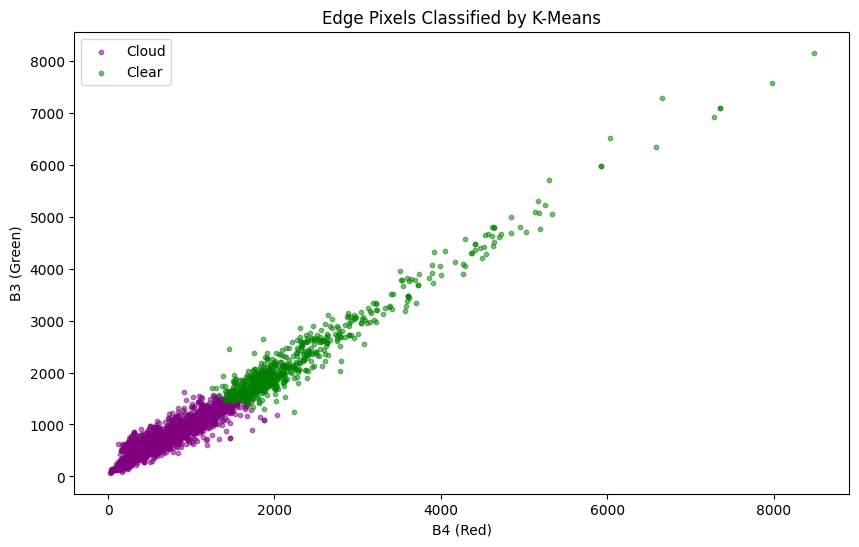

In [52]:
# Count of predicted classes
counts = edge_df['predicted_class'].value_counts()
print(counts)

# Scatter plot of edge pixels B4 vs B3 colored by predicted class ### CHANGE THIS TO YOUR OTHER BANDS ###
plt.figure(figsize=(10, 6))
for label, color in zip(['Cloud', 'Clear'], ['purple', 'green']):
    subset = edge_df[edge_df['predicted_class'] == label]
    plt.scatter(subset['B4'], subset['B3'], label=label, alpha=0.5, s=10, c=color)

plt.xlabel('B4 (Red)')
plt.ylabel('B3 (Green)')
plt.title('Edge Pixels Classified by K-Means')
plt.legend()
plt.show()


Finally, we will map this back onto earth engine via the following workflow:
1.  Export the classified edge pixels back to Earth Engine as a FeatureCollection
2. Rasterize the classified edge points into an image layer
3. Visualize refined cloud mask in Earth Engine (geemap):

Export to Earth Engine FC:

In [53]:
# Function to go the other way! This time from a dataframe to the feature collection
def df_to_ee_fc(df):
    features = []
    for _, row in df.iterrows():
        geom = ee.Geometry.Point([row['longitude'], row['latitude']])
        props = {k: float(row[k]) for k in ['B2', 'B3', 'B4', 'B8', 'probability']}
        props['predicted_class'] = row['predicted_class']
        features.append(ee.Feature(geom, props))
    return ee.FeatureCollection(features)

edge_fc = df_to_ee_fc(edge_df)

Rasterize into image layer:

In [54]:
# Map predicted class to numeric
def class_to_numeric(feature):
    cls = feature.get('predicted_class')
    return feature.set('cloud_refined', ee.Number(ee.Algorithms.If(ee.String(cls).equals('Cloud'), 1, 0)))

edge_fc_num = edge_fc.map(class_to_numeric)

# Rasterize: paint 'cloud_refined' on a blank image
refined_cloud_mask = edge_fc_num.reduceToImage(
    properties=['cloud_refined'],
    reducer=ee.Reducer.first())

# Optionally, you can combine this refined mask with your existing cloudmask for a final refined mask
final_mask = s2_sr_median.select('cloudmask').max(refined_cloud_mask).rename('cloudmask_refined')


Visualize it:

In [55]:
Map = geemap.Map(basemap='HYBRID')
Map.centerObject(AOI, 12)

# Show original cloudmask
Map.addLayer(s2_sr_median.select('cloudmask'), {'palette': ['white', 'red']}, 'Original cloudmask')

# Show refined cloudmask
Map.addLayer(final_mask.selfMask(), {'palette': ['blue']}, 'Refined cloudmask')

Map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Hopefully, what you should now see above is a patch of downtown Auckland that has your s2cloudless cloudmask and a scatter of blue pixels (i.e. the sample from within the AOI) that k-means has decided is cloud.

Your answer to Q5 should see this scatter of 'new cloudy' pixels be better associated with the known clouds than if you leave it as the default bands that I have provided.





(6) Exercise: take all you have learned in this lab and carry out the following improvements:
1. Increase the K-means sampling to be more representative of the whole scene. This means; sample regions for cloud, clear and cloud edge that are not just over downtown Auckland but from across multiple landcover types.
2. Take the model that you have trained here using SciKitLearn and use it to classify edge pixels across a whole satellite image.

Present your results in **two** figures. The first should show the results of upgrades to pt.1, the second the results of pt.2.

(15 pts)

To get you started on item 2, this might be how you plan out your workflow given that you cannot upload a python ML model directly to Earth Engine:
- Extract cluster centres from Python k-means.
- Pass centres as constants into EE.
- Write a per-pixel classification function assigning nearest cluster centre.
- Apply this function to edge pixels or the whole image as needed.

In [57]:
import ee
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Define multi-landcover sample regions across the entire scene
# Cloud core & thick cloud (white/bright spectral signature)
roi_cloud = ee.Geometry.Polygon([
    [[174.65, -36.70], [174.75, -36.70], [174.75, -36.78], [174.65, -36.78]]
])
# Clear ocean / deep water (low NIR/SWIR reflectance)
roi_clear_water = ee.Geometry.Polygon([
    [[174.90, -36.65], [175.05, -36.65], [175.05, -36.80], [174.90, -36.80]]
])
# Clear forest / dense vegetation (high NIR, moderate VIS)
roi_clear_veg = ee.Geometry.Polygon([
    [[174.50, -36.95], [174.65, -36.95], [174.65, -37.05], [174.50, -37.05]]
])
# Bare ground / Urban Auckland (high broad-spectrum reflectance, potential cloud confounder)
roi_urban_bare = ee.Geometry.Polygon([
    [[174.72, -36.83], [174.80, -36.83], [174.80, -36.90], [174.72, -36.90]]
])
# Cloud edges & thin cirrus (intermediate/borderline reflectance)
roi_cloud_edge = ee.Geometry.Polygon([
    [[174.60, -36.78], [174.68, -36.78], [174.68, -36.85], [174.60, -36.85]]
])

# Combine all sampling regions into a single MultiGeometry
combined_sampling_roi = ee.Geometry.MultiPolygon([
    roi_cloud.coordinates().get(0),
    roi_clear_water.coordinates().get(0),
    roi_clear_veg.coordinates().get(0),
    roi_urban_bare.coordinates().get(0),
    roi_cloud_edge.coordinates().get(0)
])

# 2. Select input bands for clustering (Blue, Green, Red, NIR, SWIR1, SWIR2, and s2cloudless probability)
input_bands = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'probability']

# Extract stratified sample pixels across the scene
sample_pixels = s2_sr_mosaic.select(input_bands).sample(
    region=combined_sampling_roi,
    scale=20,
    numPixels=15000,
    geometries=False
)

# Convert Earth Engine table to NumPy array for SciKit-Learn
sample_dict = sample_pixels.reduceColumns(ee.Reducer.toList().repeat(len(input_bands)), input_bands).getInfo()
X_sample = np.array(sample_dict['list']).T

# 3. Fit K-Means Model in Python (k=5 clusters: clear water, clear veg, urban/bare, thick cloud, cloud edge)
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(X_sample)

# Extract cluster centers to pass directly into Earth Engine
cluster_centers = kmeans.cluster_centers_.tolist()
print("Extracted Cluster Centers (Python KMeans):")
print(cluster_centers)

Extracted Cluster Centers (Python KMeans):
[[1024.8866354654315, 1143.0114404576198, 1115.6578263130477, 2207.9313572543083, 1860.7321892875623, 1468.750910036414, 38.60998439937601], [316.9229082937656, 478.58531238582134, 317.43807088052046, 2831.2838874680447, 1234.1815856777403, 634.7625137011419, 31.017902813299262], [498.196945337622, 835.700160771703, 570.4646302250791, 4296.707395498359, 2067.643890675232, 1102.2741157556277, 34.01205787781353], [390.9167180752658, 467.3386798272794, 389.8778531770609, 1395.9086983343298, 834.0752621838265, 510.9901295496635, 25.551511412708237], [2717.5135135135233, 2788.1544401544534, 2726.2316602316723, 3289.637065637064, 2827.3899613899603, 2453.5212355212298, 32.15444015444015]]


In [78]:
# 1. Convert Python cluster centers into Earth Engine Array/List constants
ee_cluster_centers = ee.Array(cluster_centers)

# 2. Function to assign each pixel to its nearest K-Means cluster center
def classify_kmeans_ee(img, bands, centers):
    # Select feature bands and convert to array image
    array_img = img.select(bands).toArray()

    # Compute Euclidean distance: sqrt(sum((x - center)^2))
    def compute_distance(center):
        center_array = ee.Image.constant(ee.Array(center))
        diff = array_img.subtract(center_array)
        # Using pow(2) for squaring is often preferred over multiply(diff)
        return diff.pow(2).arrayReduce(ee.Reducer.sum(), [0]).sqrt().arrayGet([0])

    # Map distance calculation over all centroid vectors to get an ImageCollection of scalar distance images
    distance_images = ee.ImageCollection(
        ee.List(centers).map(compute_distance)
    )
    # Convert the ImageCollection to a multi-band Image
    distances_image = distance_images.toBands()

    # Find cluster index with minimum distance using ee.Reducer.argmin()
    # min_cluster = distances_image.reduce(ee.Reducer.argmin()).rename('cluster_id')
    # return min_cluster
    min_cluster = distances_image.toArray().arrayArgMin(0).arrayGet([0])
    return min_cluster

# 3. Classify whole scene
classified_full_scene = classify_kmeans_ee(s2_sr_mosaic, input_bands, cluster_centers)

# 4. Isolate Cloud Edge Pixels using s2cloudless buffer/thresholding logic
s2_cloud_probability = s2_sr_mosaic.select('probability')
heavy_cloud_mask = s2_cloud_probability.gt(60) # High confidence core clouds
potential_edge_mask = s2_cloud_probability.gt(15).And(s2_cloud_probability.lte(60)) # Borderline/Edge region

# Mask classified image to apply specifically over identified edge regions
edge_classified = classified_full_scene.updateMask(potential_edge_mask)

AttributeError: 'Image' object has no attribute 'arrayArgMin'